# Fiscal Assessment · April 6–8, 2027 S.T.E.A.M. Convention
**Hakeem · Fiscal Impact dashboard research**

**Planning scenario:** approximately 15,000 attendees, Tuesday–Thursday April 6–8, 2027. The original candidate window is April 6–12. These dates are planning inputs, not statistically estimated outputs.

We ask: what do the available fiscal observations show, what trade-offs accompany the selected weekday pattern, and what can the separate convention assumptions tell us about potential receipts and organizer costs?

This notebook is local and read-only with respect to source data and S2. It does not change the shared dashboard. Charts use Seaborn/Matplotlib; pandas is sufficient for 36,000 fiscal observations. No Spark startup, model fitting or external data download is required.

**Evidence boundary:** synthetic observations end in January 2026; there is no observed April 2027 or labeled convention treatment/control. Calendar analogues are not forecasts, causal impacts or proof that the selected dates are optimal. Currency and accounting grain are unconfirmed; historical values are labeled source units.


In [1]:
import json
import hashlib
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, FileLink

from sparkcityx.day5 import select_sources
from sparkcityx.fiscal_analysis import (
    EVENT_START, EVENT_END, MEASURES, WEEKDAYS, validate_fiscal, daily_summary,
    monthly_summary, trend_statistics, prior_only_flags,
    calendar_analogues, matched_week_comparisons, convention_fiscal_scenarios,
)

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "src/sparkcityx").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Start inside SparkCity_Capstone.")
DAY4_RUN = "20260914T205935811311Z"
CONVENTION_RUN = "20260914T211931530828Z"
day4, day3, source_manifest, previous = select_sources(ROOT, DAY4_RUN)
convention_path = ROOT / "data/processed/convention" / CONVENTION_RUN
required = ["sensor_id", "timestamp", "revenue", "expense", "location_lat", "location_lon"]
frame = validate_fiscal(pd.read_parquet(day3 / "features/fiscal", columns=required))
expected = next(r["rows"] for r in previous["features"] if r["dataset"] == "fiscal")
assert len(frame) == expected
assert EVENT_START.day_name() == "Tuesday" and EVENT_END.day_name() == "Thursday"
assert (EVENT_END - EVENT_START).days + 1 == 3
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUTPUT = ROOT / "data/processed/fiscal_analysis" / RUN_ID
OUTPUT.mkdir(parents=True, exist_ok=False)
(OUTPUT / "manifest.json").write_text(json.dumps({"status": "running", "run_id": RUN_ID}))
sns.set_theme(style="whitegrid", context="notebook")
LABELS = {"revenue": "Revenue", "expense": "Expense", "net_per_observation": "Revenue − expense"}
charts = []
def save_chart(fig, name):
    fig.savefig(OUTPUT / (name + ".png"), dpi=145, bbox_inches="tight")
    charts.append(name + ".png")
    if plt.get_backend().lower() != 'agg':
        plt.show()
    plt.close(fig)
print("Fiscal source:", day3)
print("Event:", EVENT_START.date(), "through", EVENT_END.date())
print("Output:", OUTPUT)


Fiscal source: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/day3/20260914T142210469836Z
Event: 2027-04-07 through 2027-04-09
Output: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/fiscal_analysis/20260917T190735550682Z


## 1. Data quality, coverage and statistical unit
Check required fields, finite numbers, nonnegative revenue/expense, coordinate bounds and unique sensor/timestamp keys. Keep valid extremes; this is not a second cleaning pass.

There is one record every 15 minutes *across the dataset*, not a 15-minute series for each sensor. Changing coordinates prevent treating a sensor as a fixed business. Daily summaries pool different contributing sensors. Without confirmation that values are disjoint period flows, summing readings is not a defensible city revenue total.


In [2]:
daily = daily_summary(frame)
monthly = monthly_summary(frame)
statistics = frame[MEASURES].describe(percentiles=[.1, .25, .5, .75, .9]).T
gap_hours = frame.groupby("sensor_id").timestamp.diff().dt.total_seconds() / 3600
stable = frame.groupby("sensor_id")[["location_lat", "location_lon"]].nunique().max(axis=1).eq(1)
audit = {
    "rows": len(frame), "sensor_ids": frame.sensor_id.nunique(),
    "start": str(frame.timestamp.min()), "end": str(frame.timestamp.max()),
    "observed_days": int(daily.observations.notna().sum()),
    "missing_calendar_days": int(daily.observations.isna().sum()),
    "daily_rows_min": int(daily.observations.min()), "daily_rows_max": int(daily.observations.max()),
    "median_sensor_gap_hours": float(gap_hours.median()),
    "stable_location_sensors": int(stable.sum()),
    "negative_observation_share": float((frame.net_per_observation < 0).mean()),
    "complete_aprils": [m for m, r in monthly.iterrows() if m.endswith("-04") and r.complete_month],
}
display(pd.Series(audit, name="coverage"))
display(statistics)
display(monthly)
assert int(daily.observations.sum()) == len(frame)
assert np.allclose(daily.net_per_observation, daily.revenue - daily.expense, equal_nan=True)


rows                                        36000
sensor_ids                                   1200
start                         2025-01-01 00:00:00
end                           2026-01-10 23:45:00
observed_days                                 375
missing_calendar_days                           0
daily_rows_min                                 96
daily_rows_max                                 96
median_sensor_gap_hours                     300.0
stable_location_sensors                         0
negative_observation_share               0.129778
complete_aprils                         [2025-04]
Name: coverage, dtype: object

,count,mean,std,min,10%,25%,50%,75%,90%,max
revenue,36000.0,269.636823,359.254863,0.0,12.329,30.79,106.25,324.6175,893.370,1708.98
expense,36000.0,94.112265,139.744527,0.0,2.460,6.13,22.95,126.8325,352.441,499.98
net_per_observation,36000.0,175.524558,296.088085,-491.0,-4.671,14.37,50.27,209.4050,643.858,1632.66


,observations,observed_days,revenue,expense,net_per_observation,calendar_days,complete_month
month,,,,,,,
2025-01,2976,31,223.320087,95.955181,127.364906,31,True
2025-02,2688,28,240.710406,94.790450,145.919955,28,True
2025-03,2976,31,271.288602,94.278290,177.010312,31,True
2025-04,2880,30,291.971816,88.299021,203.672795,30,True
2025-05,2976,31,313.535121,93.126727,220.408394,31,True
2025-06,2880,30,328.754399,95.765854,232.988545,30,True
2025-07,2976,31,311.458229,95.828269,215.629960,31,True
2025-08,2976,31,303.267641,95.541025,207.726616,31,True
2025-09,2880,30,270.941802,92.946979,177.994823,30,True


## 2. Longitudinal trends
Daily observation means with trailing 7- and 30-calendar-day smoothing. A missing day invalidates a complete-window rolling statistic; no zero filling or interpolation is used. Lines are descriptive, not forecasts.

The fitted slope below is a whole-span summary, not seasonally adjusted growth. One seasonal cycle can produce a slope without a persistent trend. First/last 30-day differences likewise cannot separate seasonality from growth.


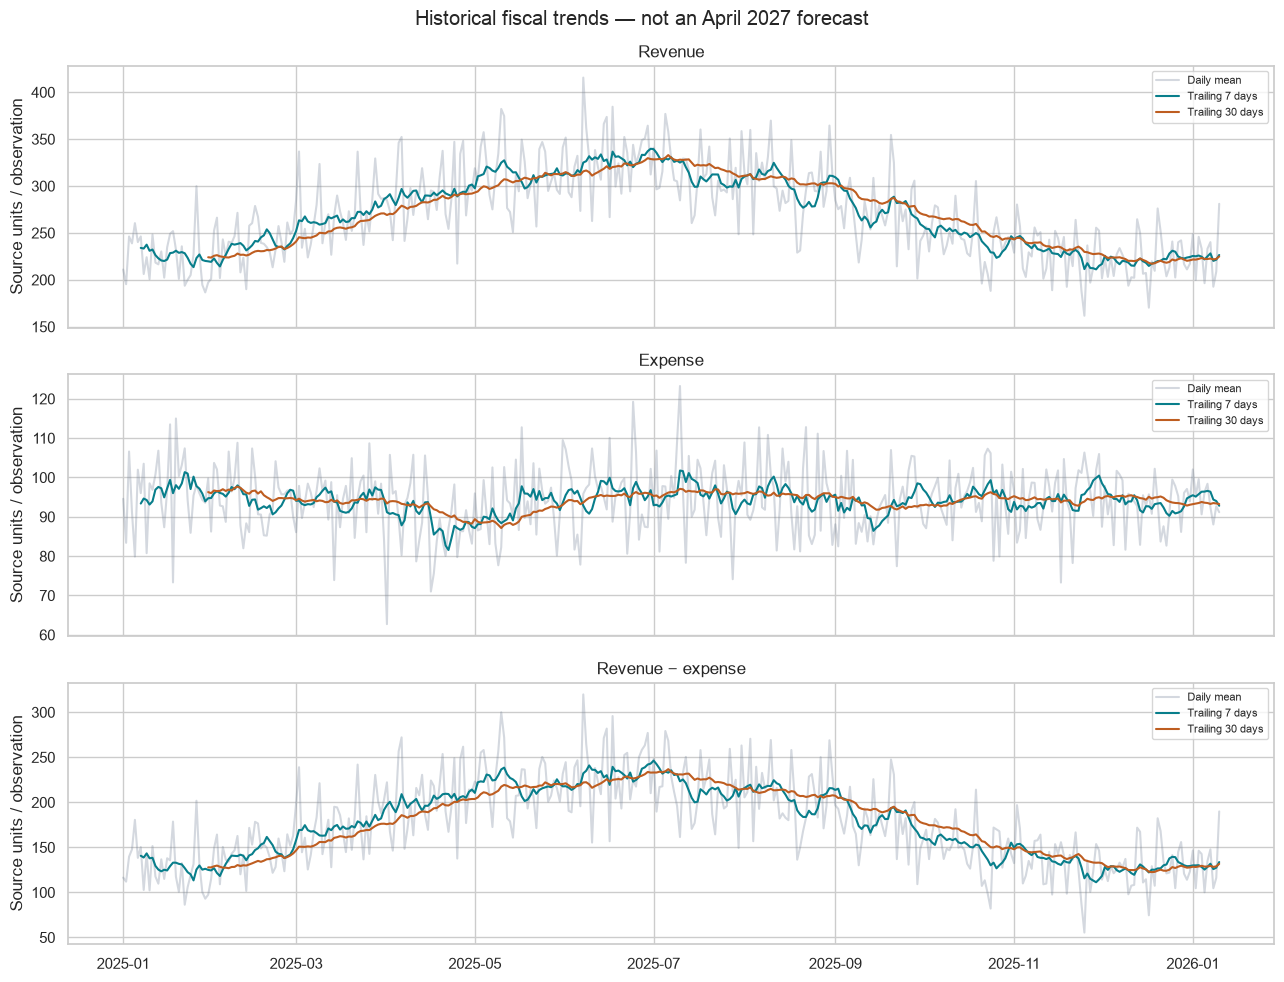

,metric,observed_days,slope_source_units_per_day,r_squared,first_30_calendar_days_mean,last_30_calendar_days_mean
0,revenue,375,-0.073769,0.028404,224.060694,224.915667
1,expense,375,0.000469,0.000035,96.278906,93.250691
2,net_per_observation,375,-0.074238,0.027901,127.781788,131.664976


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for ax, metric in zip(axes, MEASURES):
    ax.plot(daily.index, daily[metric], alpha=.3, color="#718096", label="Daily mean")
    ax.plot(daily.index, daily[metric + "_rolling_7d"], color="#087e8b", label="Trailing 7 days")
    ax.plot(daily.index, daily[metric + "_rolling_30d"], color="#be5d20", label="Trailing 30 days")
    ax.set(title=LABELS[metric], ylabel="Source units / observation")
    ax.legend(fontsize=8)
fig.suptitle("Historical fiscal trends — not an April 2027 forecast")
fig.tight_layout()
save_chart(fig, "01_historical_trends")
trends = trend_statistics(daily)
display(trends)


## 3. Distribution, typical values and downside
Compare the mean with the median; a small number of large readings can dominate an average. The negative share means expense exceeds revenue *in an observation*, not that the city or organizer is losing money. No percentage margin divides by zero-revenue observations.


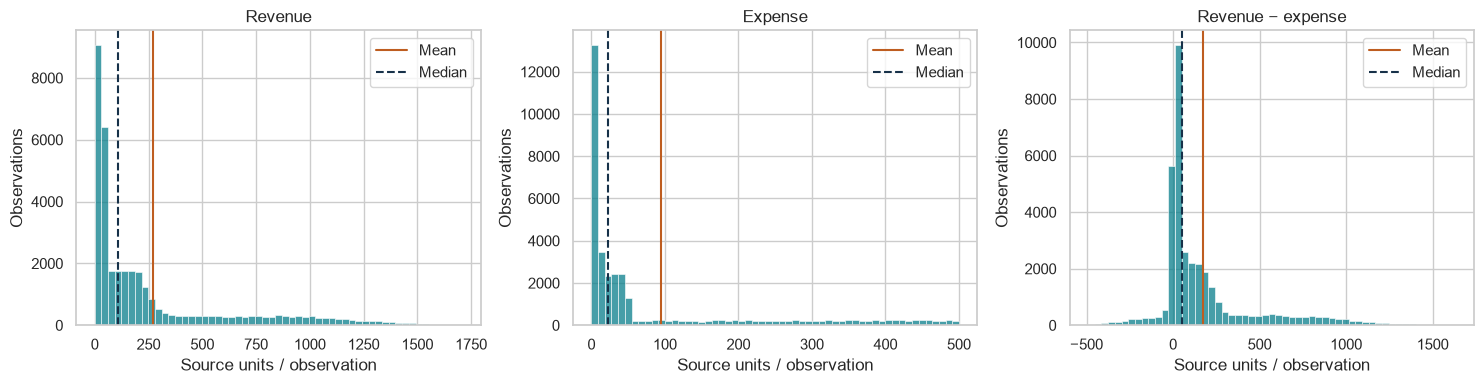

Expense exceeds revenue in 13.0% of observations.
These pooled distributions can reflect the generator's zone mixture, not a single population of businesses.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, MEASURES):
    sns.histplot(frame, x=metric, bins=55, ax=ax, color="#087e8b")
    ax.axvline(frame[metric].mean(), color="#be5d20", label="Mean")
    ax.axvline(frame[metric].median(), color="#173149", linestyle="--", label="Median")
    ax.set(title=LABELS[metric], xlabel="Source units / observation", ylabel="Observations")
    ax.legend()
fig.tight_layout()
save_chart(fig, "02_distributions")
print(f"Expense exceeds revenue in {audit['negative_observation_share']:.1%} of observations.")
print("These pooled distributions can reflect the generator's zone mixture, not a single population of businesses.")


## 4. Weekday and month patterns
Use **daily means** in weekday boxplots; the boxes describe the spread of observed days, not confidence intervals. Complete Monday–Sunday weeks provide descriptive within-week weekend-minus-weekday comparisons.

The current generator explicitly multiplies revenue by a seasonal sine factor (amplitude 20%) and a 1.15 weekend factor, but does not apply those factors to expense. These are designed synthetic effects, not independently discovered economic laws. With 36,000 generated zones, its fiscal `(index * 4) % zone_count` sampling visits three of six zone-type positions; do not claim representative citywide or commercial-sector coverage. This is a code-design audit, not a validated spatial classification of individual records.


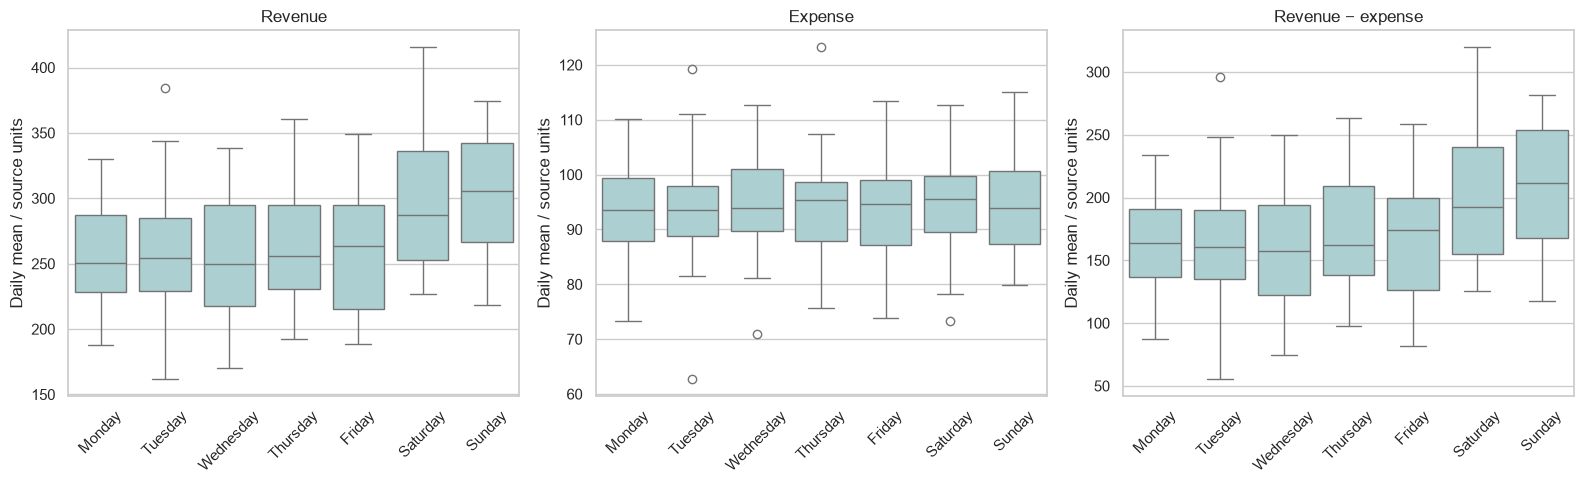

,complete_weeks,mean,median,min,max
metric,,,,,
expense,52,0.602786,0.120266,-12.916375,17.916094
net_per_observation,52,39.069806,38.728552,1.529604,80.093167
revenue,52,39.672592,39.355516,9.794094,87.298656


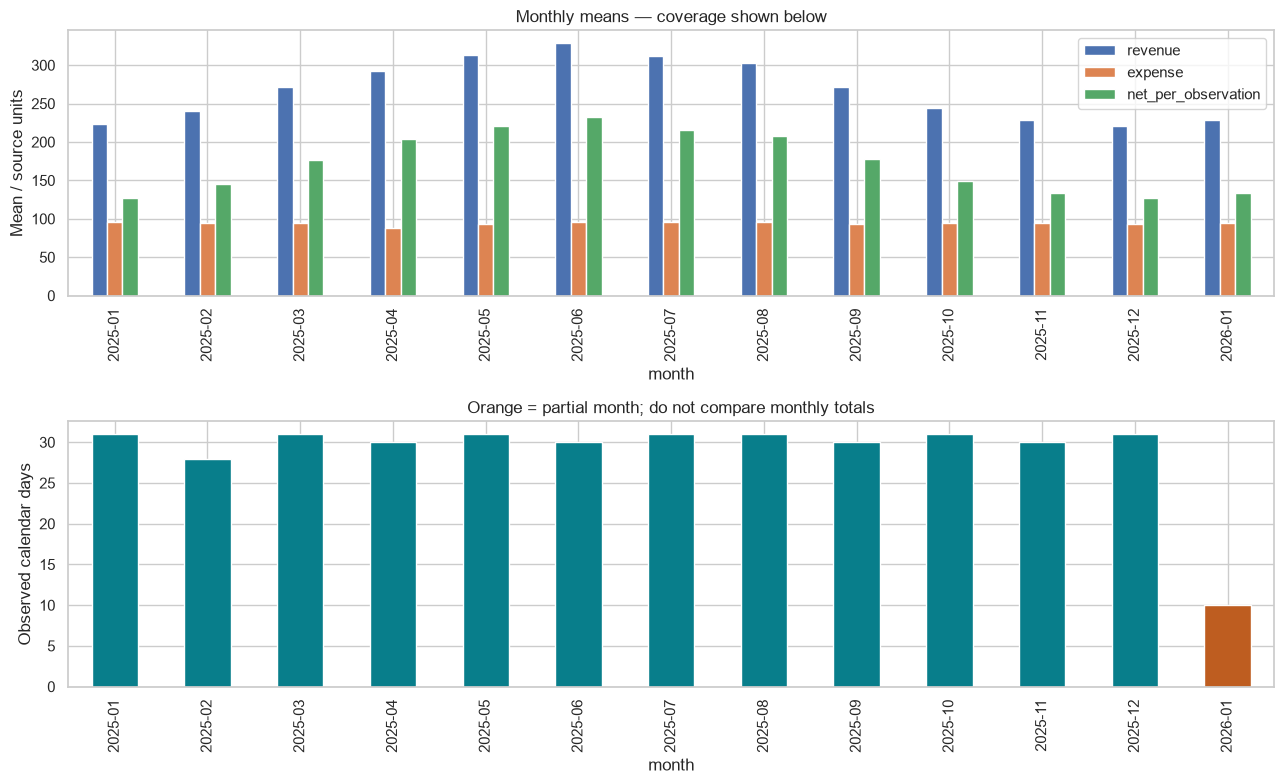

In [5]:
long_daily = daily.reset_index().melt(id_vars=["day", "weekday"], value_vars=MEASURES,
                                      var_name="metric", value_name="value")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, MEASURES):
    sns.boxplot(long_daily[long_daily.metric == metric], x="weekday", y="value",
                order=WEEKDAYS, color="#a6d4d8", ax=ax)
    ax.set(title=LABELS[metric], xlabel="", ylabel="Daily mean / source units")
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
save_chart(fig, "03_weekday_patterns")
weekly = matched_week_comparisons(daily)
weekly_summary = weekly.groupby("metric").weekend_minus_weekday.agg(["count", "mean", "median", "min", "max"])
display(weekly_summary.rename(columns={"count": "complete_weeks"}))
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
monthly[["revenue", "expense", "net_per_observation"]].plot.bar(ax=axes[0])
axes[0].set(ylabel="Mean / source units", title="Monthly means — coverage shown below")
monthly.observed_days.plot.bar(ax=axes[1], color=["#087e8b" if v else "#be5d20" for v in monthly.complete_month])
axes[1].set(ylabel="Observed calendar days", title="Orange = partial month; do not compare monthly totals")
fig.tight_layout()
save_chart(fig, "04_monthly_patterns")


## 5. Relationships and unusual days
Revenue/expense correlation is descriptive. Shared zone-type scales can induce pooled association; it does not show that increasing expenses causes revenue. Compare observation-level and daily-mean correlations instead of conflating their statistical units.

Review flags compare a day's mean with the **previous** 28 complete days using a median/MAD score. Threshold 3.5 is an exploratory rule, not a calibrated false-positive rate. Zero prior MAD or incomplete history is unassessed. Flags are retained and are not evidence of conventions.


,level,rows,pearson,spearman
0,individual observations,36000,0.606770,0.714398
1,daily means,375,0.003857,-0.005317


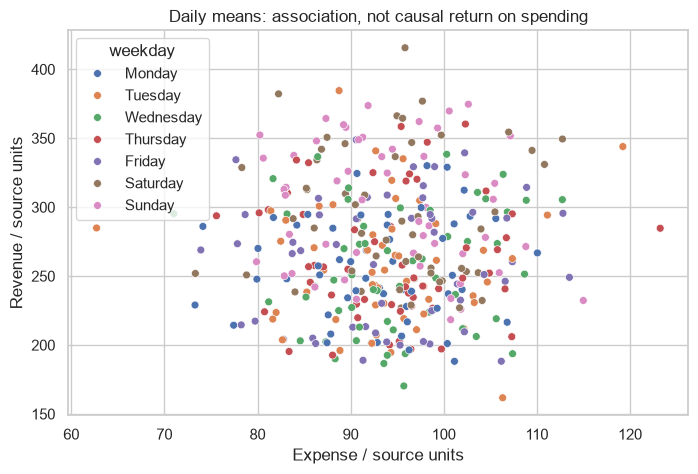

,assessed,review_flag
metric,,
expense,347,4
net_per_observation,347,3
revenue,347,2


,day,metric,value,prior_median,prior_mad,review_score,assessed,review_flag
465,2025-04-01,expense,62.716354,95.858385,3.259427,-6.858248,True,True
810,2025-03-02,net_per_observation,238.960208,149.203906,13.641771,4.437819,True,True
511,2025-05-17,expense,112.748021,86.995156,4.179010,4.156497,True,True
60,2025-03-02,revenue,336.826771,240.472292,16.840469,3.859163,True,True
447,2025-03-14,expense,73.912188,95.966875,3.935573,-3.779795,True,True
565,2025-07-10,expense,123.244896,95.832604,4.981927,3.711277,True,True
817,2025-03-09,net_per_observation,221.206354,152.469740,12.710469,3.647556,True,True
94,2025-04-05,revenue,346.064479,273.115781,13.638750,3.607600,True,True
1078,2025-11-25,net_per_observation,55.411667,141.298073,16.232865,-3.568655,True,True


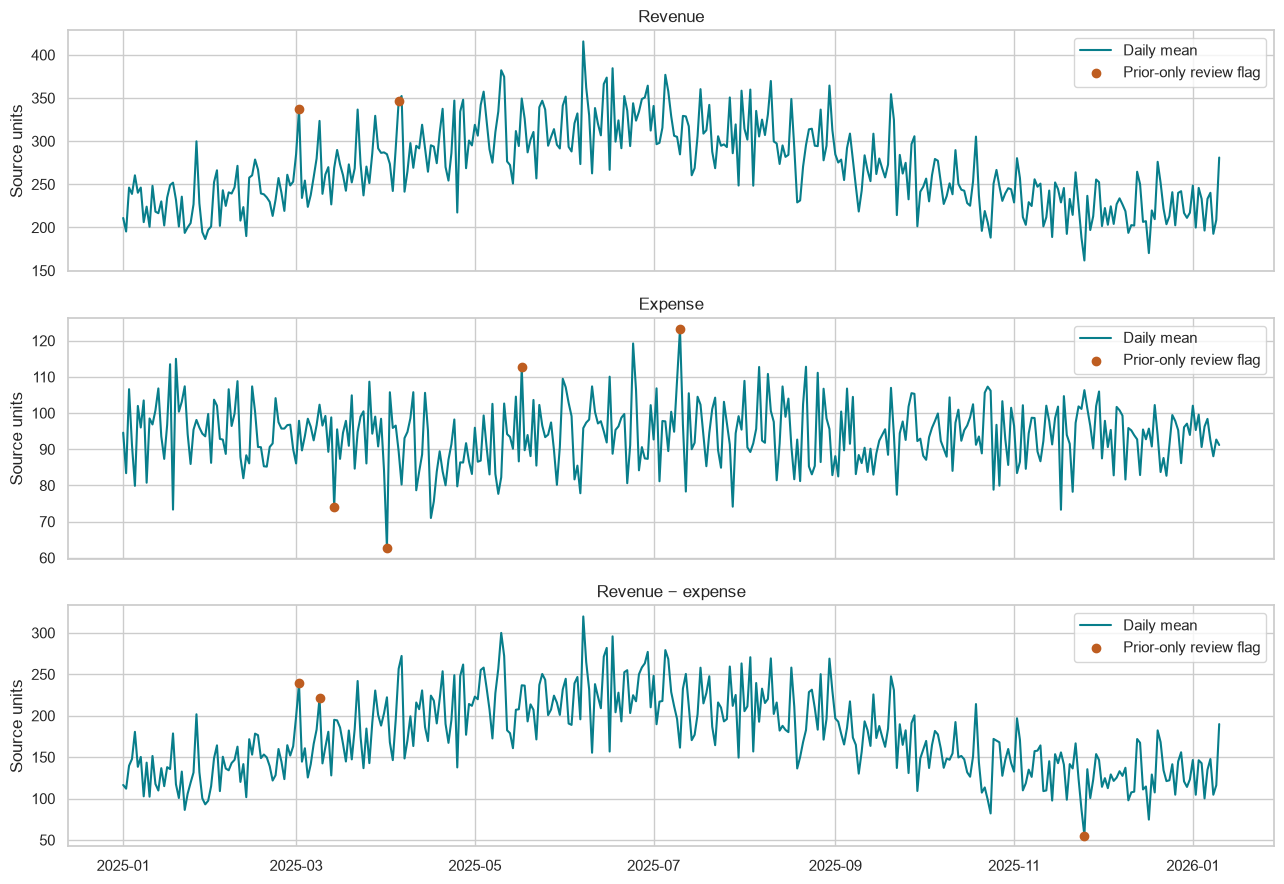

In [6]:
correlations = pd.DataFrame([
    {"level": level, "rows": len(data), "pearson": data.revenue.corr(data.expense),
     "spearman": data.revenue.rank().corr(data.expense.rank())}
    for level, data in [("individual observations", frame), ("daily means", daily.dropna(subset=MEASURES))]
])
display(correlations)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(daily, x="expense", y="revenue", hue="weekday", hue_order=WEEKDAYS, ax=ax, s=32)
ax.set(title="Daily means: association, not causal return on spending",
       xlabel="Expense / source units", ylabel="Revenue / source units")
save_chart(fig, "05_revenue_expense")
flags = prior_only_flags(daily)
display(flags.groupby("metric")[["assessed", "review_flag"]].sum())
display(flags[flags.review_flag].sort_values("review_score", key=abs, ascending=False).head(12))
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, metric in zip(axes, MEASURES):
    subset = flags[flags.metric == metric]
    ax.plot(subset.day, subset.value, color="#087e8b", label="Daily mean")
    ax.scatter(subset.loc[subset.review_flag, "day"], subset.loc[subset.review_flag, "value"],
               color="#be5d20", label="Prior-only review flag", zorder=3)
    ax.set(title=LABELS[metric], ylabel="Source units")
    ax.legend()
fig.tight_layout()
save_chart(fig, "06_review_flags")


## 6. Fair comparison of April candidate windows
Compare all five possible three-day windows within April 6–12, 2027. For each candidate, collect complete sequences with the same starting weekday wholly within **April 2025**. Summarize the observation-weighted mean within each historical three-day window.

The marker is the mean across its historical analogues; bars show their **observed minimum–maximum**, not confidence or prediction intervals. Analogue windows overlap across candidates and are not independent experiments. There are only four matching windows per candidate in the current data.

The chosen Tuesday–Thursday dates avoid the generator's weekend premium. If weekend-inclusive analogues have higher revenue, report that trade-off rather than hiding it. No historical source-unit value is converted into a 2027 dollar forecast.


,candidate_start,candidate_end,selected,metric,analogue_windows,mean,minimum,maximum
0,2027-04-07,2027-04-09,True,revenue,4,281.961398,269.274028,287.829653
1,2027-04-07,2027-04-09,True,expense,4,90.076267,76.799792,99.391424
2,2027-04-07,2027-04-09,True,net_per_observation,4,191.885130,169.882604,211.029861
3,2027-04-08,2027-04-10,False,revenue,4,292.706155,285.159757,299.577708
4,2027-04-08,2027-04-10,False,expense,4,88.605547,82.943472,93.941007
5,2027-04-08,2027-04-10,False,net_per_observation,4,204.100608,195.738438,211.461319
6,2027-04-09,2027-04-11,False,revenue,4,309.765720,299.891528,330.111771
7,2027-04-09,2027-04-11,False,expense,4,85.567873,83.677778,88.729201
8,2027-04-09,2027-04-11,False,net_per_observation,4,224.197847,215.740174,241.382569
9,2027-04-10,2027-04-12,False,revenue,4,309.232274,300.836146,317.002326


,candidate_start,candidate_end,selected,weekend_days,historical_start,observations,revenue,expense,net_per_observation
0,2027-04-07,2027-04-09,True,0,2025-04-02,288,269.274028,99.391424,169.882604
1,2027-04-07,2027-04-09,True,0,2025-04-09,288,287.203611,94.323958,192.879653
2,2027-04-07,2027-04-09,True,0,2025-04-16,288,287.829653,76.799792,211.029861
3,2027-04-07,2027-04-09,True,0,2025-04-23,288,283.538299,89.789896,193.748403


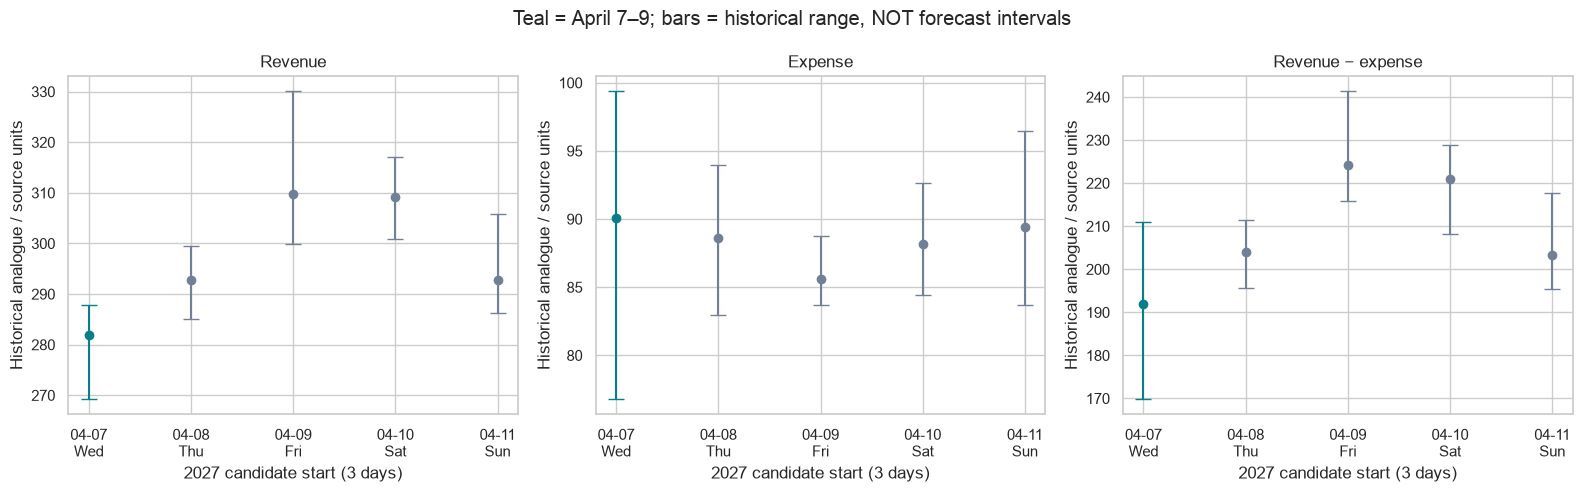

In [7]:
windows, comparison = calendar_analogues(daily, historical_year=2025)
display(comparison)
display(windows[windows.selected])
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
starts = sorted(comparison.candidate_start.unique())
for ax, metric in zip(axes, MEASURES):
    table = comparison[comparison.metric == metric].set_index("candidate_start").loc[starts]
    for index, (start, row) in enumerate(table.iterrows()):
        color = "#087e8b" if row.selected else "#718096"
        if np.isfinite(row["mean"]):
            ax.errorbar(index, row["mean"],
                        yerr=[[row["mean"] - row.minimum], [row.maximum - row["mean"]]],
                        fmt="o", color=color, capsize=6)
    ax.set_xticks(range(len(starts)), [f"{s[5:]}\n{pd.Timestamp(s).day_name()[:3]}" for s in starts])
    ax.set(title=LABELS[metric], xlabel="2027 candidate start (3 days)", ylabel="Historical analogue / source units")
fig.suptitle("Teal = April 6–8; bars = historical range, NOT forecast intervals")
fig.tight_layout()
save_chart(fig, "07_candidate_analogues")


## 7. Separate convention financial scenarios
Reuse the previously saved **three-day** convention assumptions, not the historical fiscal values. Approximately 15,000 unique attendees attending every day and three lodging nights remain model interpretations requiring confirmation.

All nine three-day venue/weather cases are checked. Their fiscal values are identical across weather within each venue in the saved model, so display one set per venue without counting duplicate draws as extra evidence. None is calibrated to April weather or actual venue quotes.

Potential visitor receipts, retained gross spending and organizer costs belong to different accounting scopes. **Do not subtract organizer cost from visitor receipts and label it city profit.** Quantile bands summarize authored assumptions, not forecast confidence. These gross scenarios exclude displacement, taxes, inflation adjustments, spending multipliers and capacity shortfalls.


,venue_archetype,metric,p10,p50,p90,draws,interpretation
0,Car-oriented,potential_gross_visitor_receipts,3.799082e+06,5.242630e+06,6.927308e+06,5000,"Authored assumption quantiles, not forecast co..."
1,Car-oriented,potential_retained_gross_spending,2.607438e+06,3.738739e+06,5.133786e+06,5000,"Authored assumption quantiles, not forecast co..."
2,Car-oriented,organizer_cost,1.500811e+06,2.046444e+06,2.796093e+06,5000,"Authored assumption quantiles, not forecast co..."
3,Mixed-access,potential_gross_visitor_receipts,3.799082e+06,5.242630e+06,6.927308e+06,5000,"Authored assumption quantiles, not forecast co..."
4,Mixed-access,potential_retained_gross_spending,2.607438e+06,3.738739e+06,5.133786e+06,5000,"Authored assumption quantiles, not forecast co..."
5,Mixed-access,organizer_cost,1.553326e+06,2.103763e+06,2.857953e+06,5000,"Authored assumption quantiles, not forecast co..."
6,Transit-focused,potential_gross_visitor_receipts,3.799082e+06,5.242630e+06,6.927308e+06,5000,"Authored assumption quantiles, not forecast co..."
7,Transit-focused,potential_retained_gross_spending,2.607438e+06,3.738739e+06,5.133786e+06,5000,"Authored assumption quantiles, not forecast co..."
8,Transit-focused,organizer_cost,1.606164e+06,2.163244e+06,2.917498e+06,5000,"Authored assumption quantiles, not forecast co..."


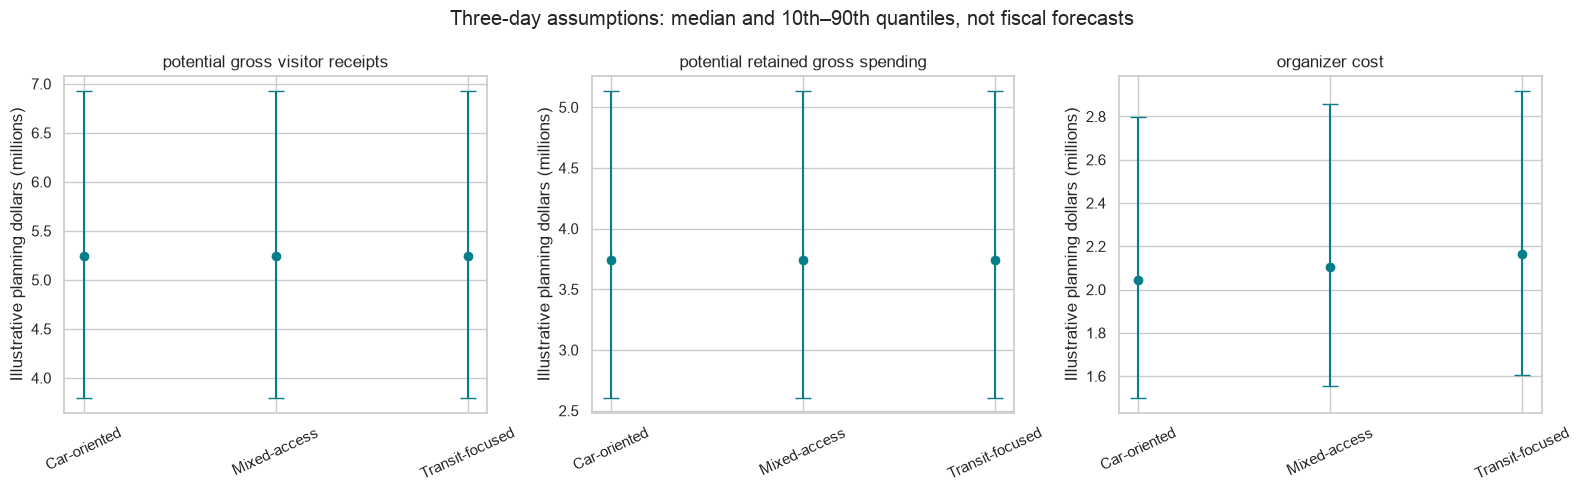

Currency: illustrative planning dollars
Attendance interpretation: unique people attending every event day
These estimates do not change between candidate dates in the saved model.


In [8]:
scenario_input_hash = hashlib.sha256((convention_path / "simulation_draws.parquet").read_bytes()).hexdigest()
scenario_summary, assumptions = convention_fiscal_scenarios(convention_path, day3.name)
display(scenario_summary)
financial_metrics = scenario_summary.metric.unique()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, financial_metrics):
    group = scenario_summary[scenario_summary.metric == metric].reset_index(drop=True)
    for i, row in group.iterrows():
        ax.errorbar(i, row.p50 / 1e6, yerr=[[(row.p50-row.p10)/1e6], [(row.p90-row.p50)/1e6]],
                    fmt="o", color="#087e8b", capsize=6)
    ax.set_xticks(range(len(group)), group.venue_archetype, rotation=25)
    ax.set(title=metric.replace("_", " "), ylabel="Illustrative planning dollars (millions)")
fig.suptitle("Three-day assumptions: median and 10th–90th quantiles, not fiscal forecasts")
fig.tight_layout()
save_chart(fig, "08_convention_assumptions")
print("Currency:", assumptions["currency"])
print("Attendance interpretation:", assumptions["attendance_interpretation"])
print("These estimates do not change between candidate dates in the saved model.")


## 8. Findings and dashboard handoff
Export aggregate tables, images, assumptions and provenance. Keep the source fiscal data and shared dashboard untouched. A complete manifest is written only after final checks. Interrupted runs remain incomplete; rerun from the beginning for a fresh output directory.

Recommended Fiscal Impact page order: scope/date → historical fiscal patterns → coverage and limitations → selected-window trade-offs → clearly separated convention scenarios. Do not label synthetic daily readings “live city revenue” or the chosen date “statistically optimal.”


In [9]:
weekday_counts = daily.groupby("weekday").observations.count().reindex(WEEKDAYS)
selected_revenue = comparison[(comparison.selected) & (comparison.metric == "revenue")].iloc[0]
best_revenue = comparison[comparison.metric == "revenue"].sort_values("mean", ascending=False).iloc[0]
lines = [
    "# Fiscal assessment: April 6–8, 2027", "",
    "The proposed Tuesday–Thursday event dates are planning inputs, not estimated outputs.",
    f"Approximately 15,000 attendees; historical source Day 3: {day3.name}.", "",
    "## Historical evidence",
    f"- {len(frame):,} observations; {audit['observed_days']} observed days; {audit['sensor_ids']:,} sensor IDs.",
    f"- Fiscal coverage: {audit['start']} through {audit['end']}; no observed April 2027.",
    f"- Median per-sensor observation gap: {audit['median_sensor_gap_hours']:.0f} hours; "
    f"{audit['stable_location_sensors']} fixed-location sensors.",
    f"- Mean revenue {frame.revenue.mean():.2f}; median {frame.revenue.median():.2f} source units per observation.",
    f"- Expense exceeds revenue in {audit['negative_observation_share']:.1%} of observations.",
    f"- Revenue/expense Pearson correlation: {correlations.iloc[0].pearson:.3f} across observations versus {correlations.iloc[1].pearson:.3f} across daily means; aggregation changes the apparent relationship.",
    "- Currency/accounting grain unconfirmed; observations are not city totals.", "",
    "## Candidate-window comparison",
    f"- April 6–8 weekday pattern: {int(selected_revenue.analogue_windows)} complete April 2025 analogues; "
    f"mean revenue {selected_revenue['mean']:.2f} source units per observation.",
    f"- Highest historical analogue revenue among the five candidates: start {best_revenue.candidate_start}, "
    f"mean {best_revenue['mean']:.2f}. This is not a best-date recommendation.",
    "- All candidate windows use identical inclusion rules; historical min–max bars are not prediction intervals.",
    "- Revenue seasonality and a 15% weekend premium are built into the generator.",
    "- One complete April cannot establish repeatable April seasonality or a 2027 forecast.", "",
    "## Convention scenarios",
    "- Three-day financial draws reuse saved assumptions, independently of historical fiscal values.",
    "- Weather duplicates are not additional evidence; values are not date-calibrated.",
    "- Visitor receipts, retained spending and organizer costs remain separate accounting scopes.",
    "- No city-profit, tax-revenue or causal-impact estimate is supported.", "",
    "## Implications for planning",
    "- Keep the weekday-only objective explicit; do not claim it maximizes historical revenue.",
    "- Confirm actual Tuesday–Thursday venue/hotel quotes and displacement from normal business activity.",
    "- Verify attendee definition, overnight share and lodging nights before using spending totals.",
    "- Obtain organizer budget/income separately; use historical patterns as context, not a funding guarantee.",
    "- Confirm fiscal record meaning, units, geographic coverage and actual event/control data before causal work.",
]
(OUTPUT / "findings.md").write_text("\n".join(lines) + "\n")
for name, table in {
    "daily": daily.reset_index(), "monthly": monthly.reset_index(),
    "distribution_statistics": statistics.reset_index(names="metric"), "trends": trends,
    "correlations": correlations, "weekly_comparisons": weekly, "review_flags": flags,
    "candidate_windows": windows, "candidate_summary": comparison, "convention_financial_scenarios": scenario_summary,
}.items():
    table.to_csv(OUTPUT / (name + ".csv"), index=False)
(OUTPUT / "convention_assumptions.json").write_text(json.dumps(assumptions, indent=2))
import html
sections = [f"<h1>Fiscal assessment · April 6–8, 2027</h1><pre>{html.escape(chr(10).join(lines))}</pre>"]
sections += [f'<h2>{html.escape(name[:-4].replace("_", " "))}</h2><img src="{name}" alt="{html.escape(name)}">' for name in charts]
(OUTPUT / "report.html").write_text('<!doctype html><html lang="en"><meta charset="utf-8"><title>Fiscal assessment</title>'
    '<style>body{font:16px system-ui;max-width:1200px;margin:30px auto;padding:20px}img{max-width:100%}pre{white-space:pre-wrap}</style>'
    + "".join(sections) + "</html>")
select_sources(ROOT, DAY4_RUN)
assert hashlib.sha256((convention_path / "simulation_draws.parquet").read_bytes()).hexdigest() == scenario_input_hash
assert len(windows[windows.selected]) > 0
assert len(comparison.candidate_start.unique()) == 5
provenance = {
    "status": "complete", "run_id": RUN_ID, "event_start": str(EVENT_START.date()),
    "event_end": str(EVENT_END.date()), "attendees": 15000,
    "day4_run": day4.name, "day3_run": day3.name, "day2_run": source_manifest["day2_run"],
    "day1_run": source_manifest["day1_run"], "fiscal_input_sha256": source_manifest["input_sha256"]["fiscal"],
    "convention_run": CONVENTION_RUN, "simulation_sha256": scenario_input_hash,
    "generator_sha256": hashlib.sha256((ROOT / "scripts/generate-data.py").read_bytes()).hexdigest(),
    "analysis_module_sha256": hashlib.sha256((ROOT / "src/sparkcityx/fiscal_analysis.py").read_bytes()).hexdigest(),
    "notebook_sha256": hashlib.sha256((ROOT / "notebooks/Hakeem_fiscal_analysis.ipynb").read_bytes()).hexdigest(),
    "pandas": pd.__version__, "numpy": np.__version__, "seaborn": sns.__version__,
    "coverage": audit, "charts": charts, "database_writes": False,
    "claim_scope": "Descriptive synthetic historical analysis and separate authored event scenarios; no causal effect or date forecast",
}
provenance["artifacts_sha256"] = {
    p.name: hashlib.sha256(p.read_bytes()).hexdigest()
    for p in sorted(OUTPUT.iterdir()) if p.is_file() and p.name != "manifest.json"
}
(OUTPUT / "manifest.json").write_text(json.dumps(provenance, indent=2))
display(Markdown("\n".join(lines)))
display(FileLink(str(OUTPUT / "report.html")))
print("Complete:", OUTPUT)


# Fiscal assessment: April 7–9, 2027

The proposed Wednesday–Friday event dates are planning inputs, not estimated outputs.
Approximately 15,000 attendees; historical source Day 3: 20260914T142210469836Z.

## Historical evidence
- 36,000 observations; 375 observed days; 1,200 sensor IDs.
- Fiscal coverage: 2025-01-01 00:00:00 through 2026-01-10 23:45:00; no observed April 2027.
- Median per-sensor observation gap: 300 hours; 0 fixed-location sensors.
- Mean revenue 269.64; median 106.25 source units per observation.
- Expense exceeds revenue in 13.0% of observations.
- Revenue/expense Pearson correlation: 0.607 across observations versus 0.004 across daily means; aggregation changes the apparent relationship.
- Currency/accounting grain unconfirmed; observations are not city totals.

## Candidate-window comparison
- April 7–9 weekday pattern: 4 complete April 2025 analogues; mean revenue 281.96 source units per observation.
- Highest historical analogue revenue among the five candidates: start 2027-04-09, mean 309.77. This is not a best-date recommendation.
- All candidate windows use identical inclusion rules; historical min–max bars are not prediction intervals.
- Revenue seasonality and a 15% weekend premium are built into the generator.
- One complete April cannot establish repeatable April seasonality or a 2027 forecast.

## Convention scenarios
- Three-day financial draws reuse saved assumptions, independently of historical fiscal values.
- Weather duplicates are not additional evidence; values are not date-calibrated.
- Visitor receipts, retained spending and organizer costs remain separate accounting scopes.
- No city-profit, tax-revenue or causal-impact estimate is supported.

## Implications for planning
- Keep the weekday-only objective explicit; do not claim it maximizes historical revenue.
- Confirm actual Wednesday–Friday venue/hotel quotes and displacement from normal business activity.
- Verify attendee definition, overnight share and lodging nights before using spending totals.
- Obtain organizer budget/income separately; use historical patterns as context, not a funding guarantee.
- Confirm fiscal record meaning, units, geographic coverage and actual event/control data before causal work.

/Users/hakeem/Projects/SparkCity_Capstone/data/processed/fiscal_analysis/20260917T190735550682Z/report.html

Complete: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/fiscal_analysis/20260917T190735550682Z
